# Scene State Visualization and Retrieval

This notebook demonstrates how to use the `get_scene_state` API in `radarsimpy` to retrieve target meshes, transmitter/receiver channel locations, and the radar platform pointing (boresight) direction at different simulation timestamps, and how to visualize them in 3D.

In [1]:
import numpy as np
import plotly.graph_objs as go
from IPython.display import Image, display

from radarsimpy import Radar, Transmitter, Receiver, get_scene_state

# Set to True for interactive plots; False renders a static JPEG (e.g. for HTML export)
INTERACTIVE = False


def show(fig):
    if INTERACTIVE:
        fig.show()
    else:
        display(Image(fig.to_image(format="jpg", scale=2)))


## 1. Setup Radar Configuration

We configure a radar with multiple transmitter and receiver channels, and define its translation/rotation motion parameters.

In [2]:
tx = Transmitter(
    f=[24e9, 24.1e9],
    t=1e-4,
    tx_power=10,
    prp=2e-4,
    pulses=3,
    channels=[
        {"location": (0, 0.1, 0)},
        {"location": (0, -0.1, 0)}
    ],
)
rx = Receiver(
    fs=1e5,
    channels=[
        {"location": (0.2, 0, 0)}
    ],
)

# Radar starts at (0, 0, 0), moving along the X-axis, and yawing at 45 deg/s
radar = Radar(
    transmitter=tx, 
    receiver=rx,
    location=(0, 0, 0),
    speed=(2, 0, 0),
    rotation=(0, 0, 0),
    rotation_rate=(45, 0, 0)  # yawing 45 deg/s
)

## 2. Define Target

We define a static mesh target in the scene.

In [5]:
target = {
    "model": "../models/plate5x5.stl",
    "location": (10, 0, 0),
}

## 3. Retrieve Scene State at a Specific Timestamp

In [6]:
# Get the scene state at t = 1.0 second
state = get_scene_state(target, radar, timestamp=1.0)

print("--- Target Mesh ---")
print("Points shape:", state["targets"]["points"].shape)

print("\n--- Transmitter Channels ---")
print("Tx Locations:\n", state["tx_locations"])

print("\n--- Receiver Channels ---")
print("Rx Locations:\n", state["rx_locations"])

print("\n--- Radar Boresight Direction ---")
print("Radar Boresight:\n", state["radar_boresight"])

--- Target Mesh ---
Points shape: (4, 3)

--- Transmitter Channels ---
Tx Locations:
 [[ 1.9292893   0.07071068  0.        ]
 [ 2.0707107  -0.07071068  0.        ]]

--- Receiver Channels ---
Rx Locations:
 [[2.1414213  0.14142136 0.        ]]

--- Radar Boresight Direction ---
Radar Boresight:
 [0.70710677 0.70710677 0.        ]


## 4. Visualize the Scene State in 3D

Let's render the target mesh, radar Tx/Rx channel locations, and the radar platform boresight vector at `t = 1.0` seconds.

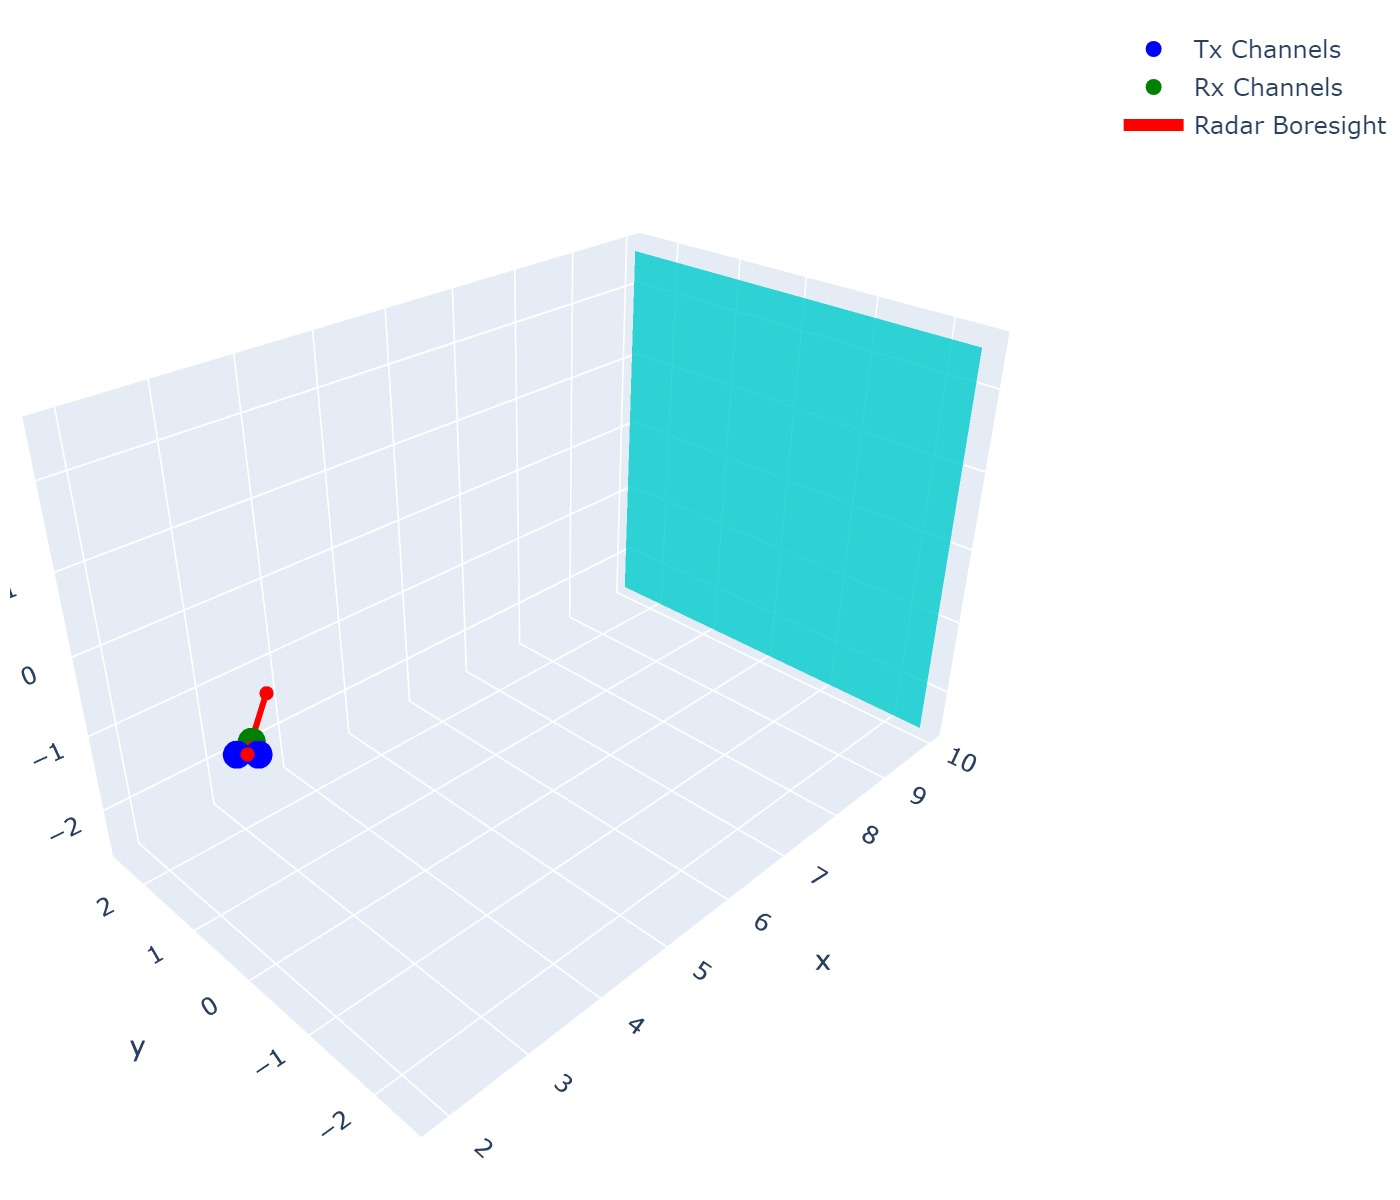

In [7]:
fig = go.Figure()

# 1. Plot target mesh
pts = state["targets"]["points"]
cells = state["targets"]["cells"]
fig.add_trace(
    go.Mesh3d(
        x=pts[:, 0],
        y=pts[:, 1],
        z=pts[:, 2],
        i=cells[:, 0],
        j=cells[:, 1],
        k=cells[:, 2],
        color="cyan",
        opacity=0.8,
        name="Target"
    )
)

# 2. Plot Tx channels (blue markers)
tx_locs = state["tx_locations"]
fig.add_trace(
    go.Scatter3d(
        x=tx_locs[:, 0],
        y=tx_locs[:, 1],
        z=tx_locs[:, 2],
        mode="markers",
        marker=dict(size=8, color="blue"),
        name="Tx Channels"
    )
)

# 3. Plot Rx channels (green markers)
rx_locs = state["rx_locations"]
fig.add_trace(
    go.Scatter3d(
        x=rx_locs[:, 0],
        y=rx_locs[:, 1],
        z=rx_locs[:, 2],
        mode="markers",
        marker=dict(size=8, color="green"),
        name="Rx Channels"
    )
)

# 4. Plot Radar Boresight (represented as a red vector originating from the platform center)
center = np.mean(tx_locs, axis=0)
bore = state["radar_boresight"]
fig.add_trace(
    go.Scatter3d(
        x=[center[0], center[0] + bore[0]],
        y=[center[1], center[1] + bore[1]],
        z=[center[2], center[2] + bore[2]],
        mode="lines+markers",
        line=dict(color="red", width=6),
        marker=dict(size=4, color="red"),
        name="Radar Boresight"
    )
)

fig["layout"]["scene"]["aspectmode"] = "data"
fig["layout"]["scene"]["camera"] = {"eye": {"x": -1.5, "y": -1.5, "z": 1.25}}
fig["layout"]["height"] = 600
fig["layout"]["margin"] = dict(l=5, r=0, b=10, t=10)

show(fig)